In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


path='C:/Users/Nicolas Catz/Documents/OpenBCI_GUI/Recordings/' # specify the path to the folder containing the data file
path='D:\\DATA\\Projets\\M1_EEG_Project\\' # specify the path to the folder containing the data file/

session='data' # specify the name of the session folder

filename='alpha_test.csv' # specify the name of the data file


data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame  

eeg_data=data.iloc[:, 1:9].to_numpy()  # select the EEG data columns (assuming they are in columns 1 to 8)
eeg_data = eeg_data.T

C:\Users\Nicolas Catz\AppData\Local\Temp\ipykernel_29180\408342580.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame


In [16]:
from scipy.signal import butter, filtfilt, iirnotch

fs = 250
print(f"Fréquence d'échantillonnage estimée : {fs:.2f} Hz")

def bandpass_filter(sig, low=1.0, high=40.0, fs=fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, freq=50.0, fs=fs, q=30):
    nyq = fs / 2
    b, a = iirnotch(freq / nyq, q)
    return filtfilt(b, a, sig)

Fréquence d'échantillonnage estimée : 250.00 Hz


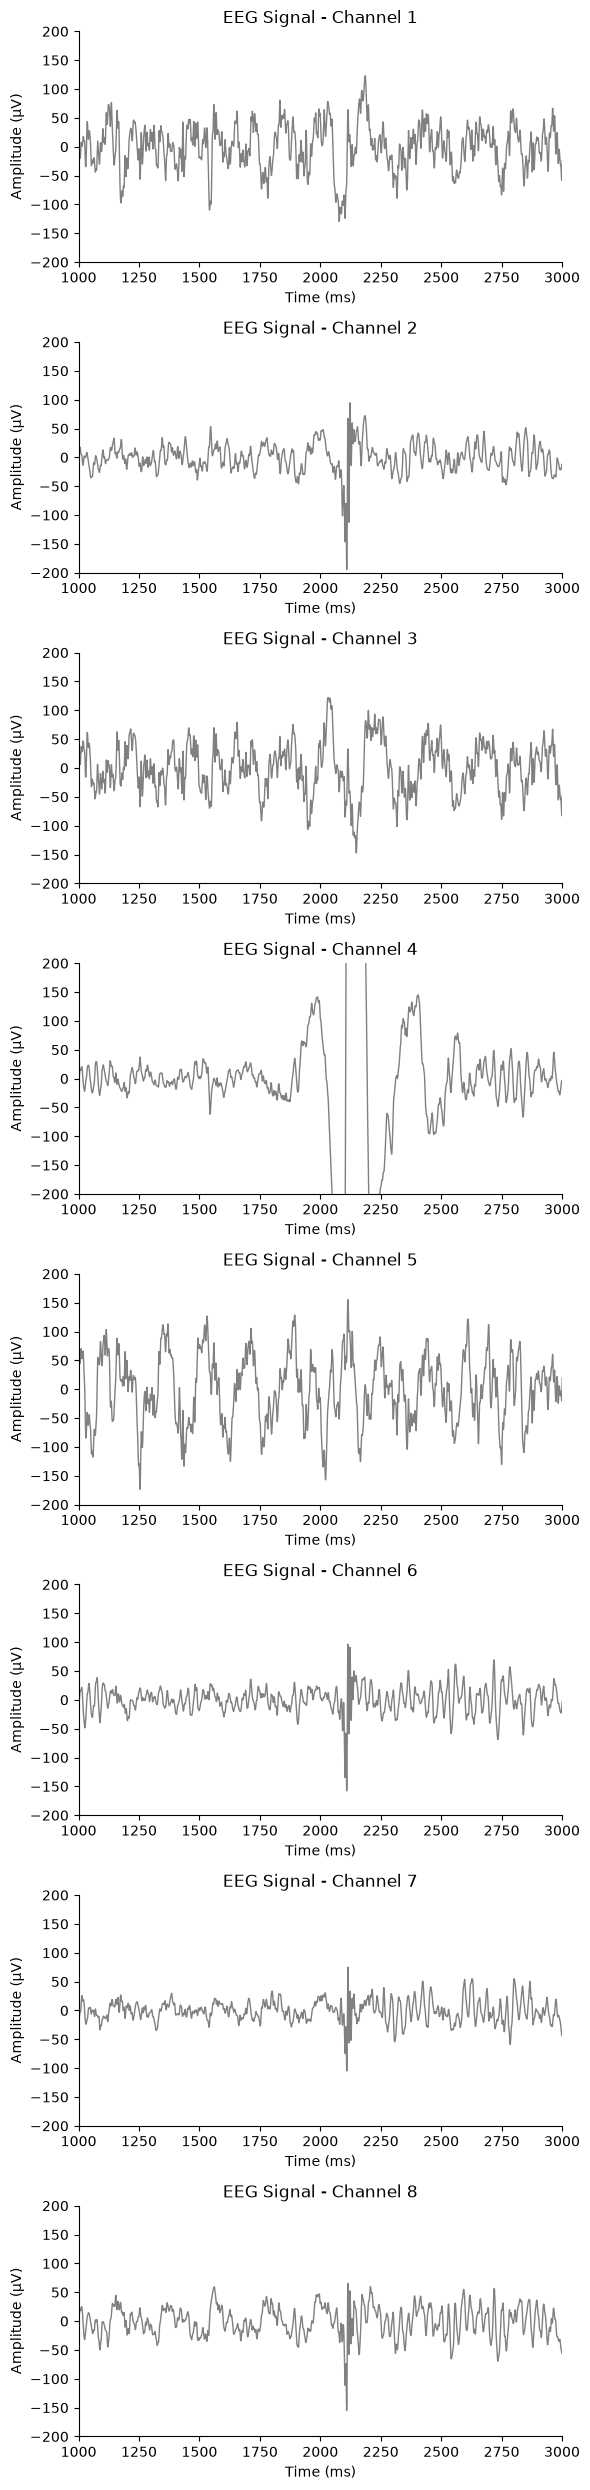

In [25]:
fig,axs=plt.subplots(8,1,figsize=(6,25))

for channel in range(0,8):  # Only process the first channel
    
    raw_signal = eeg_data[channel,0:-2]

    eeg_filtered = notch_filter(bandpass_filter(raw_signal))
    
    axs[channel].plot(eeg_filtered, color='gray', linewidth=1)
    axs[channel].set_title(f'EEG Signal - Channel {channel+1}')
    axs[channel].set_ylim(-200, 200)
    axs[channel].set_xlim(1000, 3000)
    axs[channel].set_xlabel('Time (ms)')
    axs[channel].set_ylabel('Amplitude (µV)')
    axs[channel].spines['top'].set_visible(False)
    axs[channel].spines['right'].set_visible(False)
    
plt.tight_layout()
    
